# Chris Wolfram replication notebook

The goal of this notebook is to analyze how the changes in the race question of the 2020 census explains a strange trend in how the people that identify as white-hispanic changed. 

We look at Georgia because this is what Chris Wolfram looked at. 

## Questions for meeting
1. Why Georgia? Should we look at other states individually?
2. Reasoning behind that bar graph on page 7?
3. I got similar patterns, but different numbers.

# Imports

In [107]:
import pandas as pd

import requests

import matplotlib.pyplot as plt

import us

# Functions and Variables

In [21]:
# Helper function to fetch data
def fetch_census_data(url, variables, geography, in_param=None):
    params = {
        "get": variables,
        "for": geography
    }
    if in_param:
        params["in"] = in_param
        
    response = requests.get(url, params=params)
    response.raise_for_status() # Check for errors
    
    data = response.json()
    # Convert list of lists to DataFrame
    return pd.DataFrame(data[1:], columns=data[0])

In [18]:
# API Endpoints
acs_url = "https://api.census.gov/data/2022/acs/acs5"
dec_url = "https://api.census.gov/data/2020/dec/pl"

# Variables
acs_vars = "B01001A_001E,B01001H_001E" #the former being from the ACS table, to be the population of White alone: 
                                        #"Estimate!!Total:" form "Sex by Age (White Alone)"
                                        #and the latter being from the same ACS table, to be the population of White Alone, 
                                        #Not Hispanic/Latino: "Estimate!!Total:" from "Sex by Age (White Alone, Not Hispanic or Latino)"
dec_vars = "P1_003N,P2_005N" #the former being from the PL table, "!!Total:!!Population of one race:!!White Alone)"
                            #and the latter being from the PL table, "!!Total:!!Not Hispanic or Latino!!Population 
                            #of one race:!!White alone")


# One State: Georgia

## Data

We are interested in those that answered 'Hispanic' as their ethnicity and only selected their race as 'White.' 

In [25]:
state = "state:13" #We can change this; right now, it is at 13 because that is the FIPs code for Georgia. 

In [40]:

# Fetch ACS data for tracts in Georgia
acs_tract_df = fetch_census_data(acs_url, acs_vars, "tract:*", state)
acs_tract_df['B01001A_001E'] = acs_tract_df['B01001A_001E'].astype(float) #because they read in as strings
acs_tract_df['B01001H_001E'] = acs_tract_df['B01001H_001E'].astype(float)

# Fetch Decennial data for tracts in Georgia
dec_tract_df = fetch_census_data(dec_url, dec_vars, "tract:*", state)
dec_tract_df['P1_003N'] = dec_tract_df['P1_003N'].astype(float)
dec_tract_df['P2_005N'] = dec_tract_df['P2_005N'].astype(float)

# Merge datasets on geography keys
merged_tract = pd.merge(acs_tract_df, dec_tract_df, on=["state", "county", "tract"])

# Compute the difference to get the hispanic white alone
merged_tract['ACS_HWA'] = merged_tract['B01001A_001E'] - merged_tract['B01001H_001E']
merged_tract['DEC_HWA'] = merged_tract['P1_003N'] - merged_tract['P2_005N']

## Plots

### Comparison of the PL Non-Hispanic White Population and the ACS Non-Hispanic White Population: Bar graph

On page 2 of the notebook:

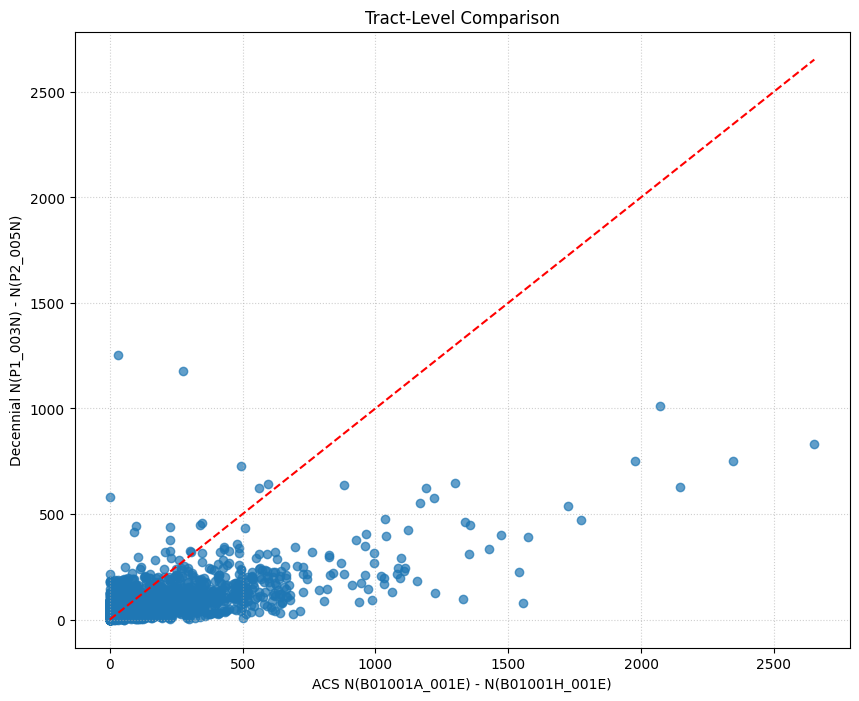

In [116]:
# Replicate the Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(merged_tract['ACS_HWA'], merged_tract['DEC_HWA'], alpha=0.7)

# Add the y=x dashed line
max_val = max(merged_tract['ACS_HWA'].max(), merged_tract['DEC_HWA'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='1:1 Line')

plt.title('Tract-Level Comparison')
plt.xlabel('ACS N(B01001A_001E) - N(B01001H_001E)')
plt.ylabel('Decennial N(P1_003N) - N(P2_005N)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

I wanted a zoomed version as well.

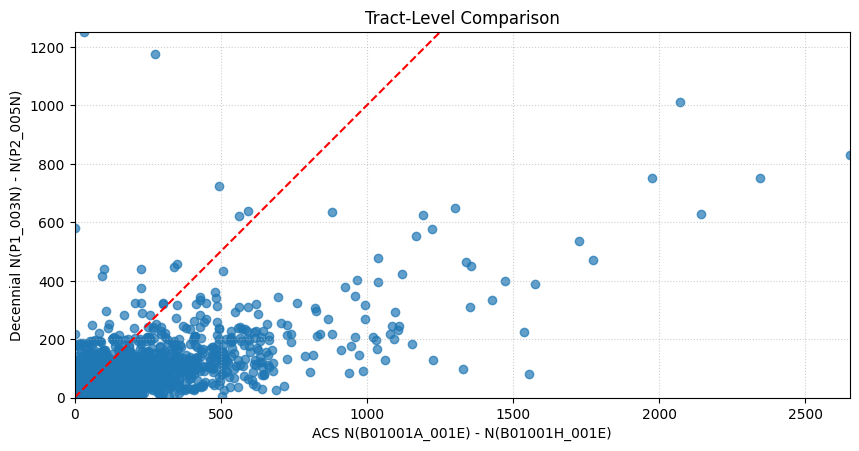

In [123]:
plt.figure(figsize=(10, 8))
plt.scatter(merged_tract['ACS_HWA'], merged_tract['DEC_HWA'], alpha=0.7)

plt.xlim(0, merged_tract['ACS_HWA'].max())
plt.ylim(0, merged_tract['DEC_HWA'].max())

# Draw y = x line (only up to the smaller max so it stays in bounds)
line_max = min(merged_tract['ACS_HWA'].max(), merged_tract['DEC_HWA'].max())
plt.plot([0, line_max], [0, line_max], 'r--', label='1:1 Line')
plt.gca().set_aspect('equal', adjustable='box')

plt.title('Tract-Level Comparison')
plt.xlabel('ACS N(B01001A_001E) - N(B01001H_001E)')
plt.ylabel('Decennial N(P1_003N) - N(P2_005N)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Now do the direct comparison:

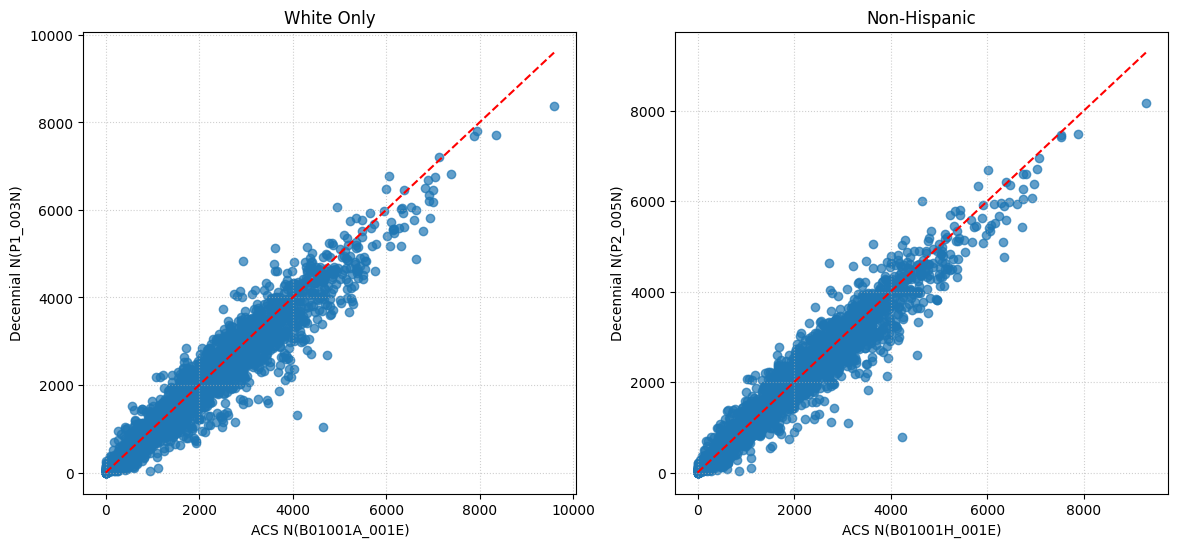

In [97]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: White only 

axs[0].scatter(merged_tract['B01001A_001E'], merged_tract['P1_003N'], alpha=0.7)

max_val1 = max(merged_tract['B01001A_001E'].max(), merged_tract['P1_003N'].max())
axs[0].plot([0, max_val1], [0, max_val1], 'r--', label='1:1 Line')

axs[0].set_title('White Only')
axs[0].set_xlabel('ACS N(B01001A_001E)')
axs[0].set_ylabel('Decennial N(P1_003N)')
axs[0].grid(True, linestyle=':', alpha=0.6)


# Right plot: Non-Hispanic
axs[1].scatter(merged_tract['B01001H_001E'], merged_tract['P2_005N'], alpha=0.7)

max_val2 = max(merged_tract['B01001H_001E'].max(), merged_tract['P2_005N'].max())
axs[1].plot([0, max_val2], [0, max_val2], 'r--', label='1:1 Line')

axs[1].set_title('Non-Hispanic')
axs[1].set_xlabel('ACS N(B01001H_001E)')
axs[1].set_ylabel('Decennial N(P2_005N)')
axs[1].grid(True, linestyle=':', alpha=0.6)

plt.show()

On page 7 of Chris's notebook, we see a graph of number of tracts with a specific number of non-hispanic white alone population. I think that he actually looks at this over all states, and not over the tracts, which is why we get different numbers (but see the same pattern). This is confusing to me. For a given tract, more people will have filled out the census than the ACS. If a tract has a certain population of Non-Hispanic White alone in the PL, it won't necessarily fall under that same category in the census. So what I think that we should see is that for the ACS, the bars should be higher for lower populations. The fact that we do not see that, is that the point of the bar graph?

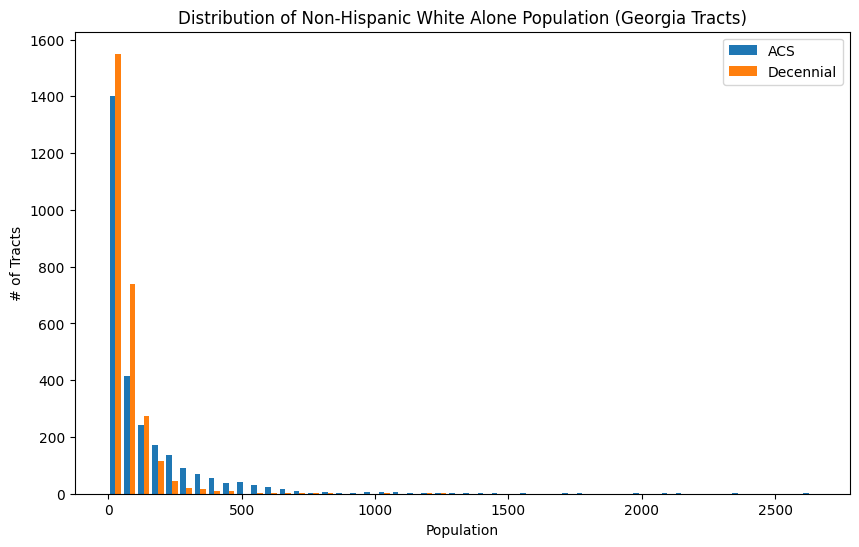

In [43]:
# Replicate the Histogram of Tract Counts
plt.figure(figsize=(10, 6))
plt.hist([merged_tract['ACS_HWA'], merged_tract['DEC_HWA']], bins=50, label=['ACS', 'Decennial'])
plt.title('Distribution of Non-Hispanic White Alone Population (Georgia Tracts)')
plt.xlabel('Population of Non-Hispanic White Alone')
plt.ylabel('# of Tracts')
plt.legend()
plt.show()

# All States

In [149]:
# Fetch ACS data for all states
acs_state_df = fetch_census_data(acs_url, acs_vars, "state:*")
acs_state_df['B01001A_001E'] = acs_state_df['B01001A_001E'].astype(float)
acs_state_df['B01001H_001E'] = acs_state_df['B01001H_001E'].astype(float)

# Fetch Decennial data for all states
dec_state_df = fetch_census_data(dec_url, dec_vars, "state:*")
dec_state_df['P1_003N'] = dec_state_df['P1_003N'].astype(float)
dec_state_df['P2_005N'] = dec_state_df['P2_005N'].astype(float)

# Merge datasets
merged_state = pd.merge(acs_state_df, dec_state_df, on="state")

# Compute the difference to get the hispanic white alone
merged_state['ACS_HWA'] = merged_state['B01001A_001E'] - merged_state['B01001H_001E']
merged_state['DEC_HWA'] = merged_state['P1_003N'] - merged_state['P2_005N']

# Get a dictionary mapping FIPS to State names (optional, for labeling like in your doc)
try:
    fips_to_state = {state.fips: state.name for state in us.states.STATES}
    merged_state['State_Name'] = merged_state['state'].map(fips_to_state)
except ImportError:
    print("Consider installing the 'us' package to get state names for plot labels.")

As Chris saw, we see the same problem with Georgia in other states as well:

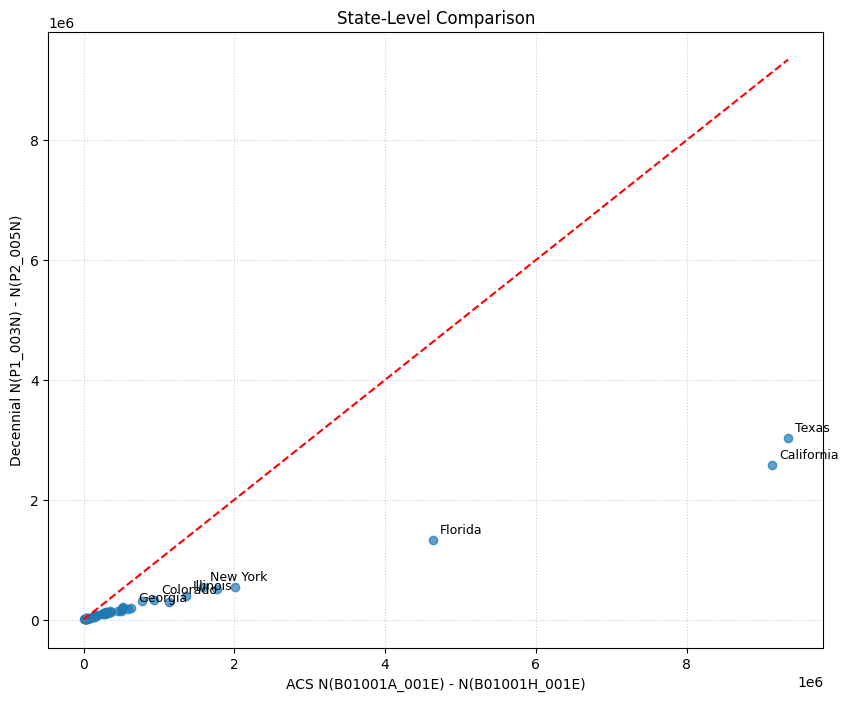

In [152]:
# Replicate the Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(merged_state['ACS_HWA'], merged_state['DEC_HWA'], alpha=0.7)

# Add the y=x dashed line
max_val = max(merged_state['ACS_HWA'].max(), merged_state['DEC_HWA'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='1:1 Line')

# Label a few prominent states (New York, Arizona, Illinois, etc.)
if 'State_Name' in merged_state.columns:
    for i, row in merged_state.iterrows():
        if row['State_Name'] in ['New York', 'Illinois', 'Colorado', 'Georgia', 'Texas', 'California', 'Florida']:
            plt.annotate(row['State_Name'], (row['ACS_HWA'], row['DEC_HWA']), fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.title('State-Level Comparison')
plt.xlabel('ACS N(B01001A_001E) - N(B01001H_001E)')
plt.ylabel('Decennial N(P1_003N) - N(P2_005N)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In the document (on page 4), the graph is cut off: we plot that one as well.

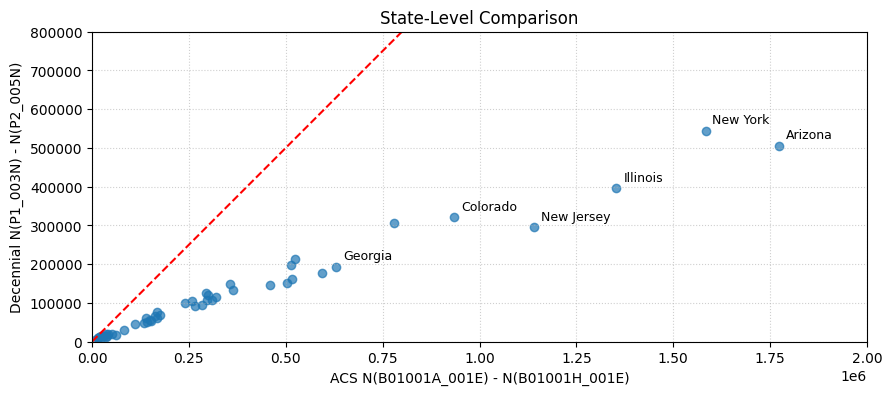

In [127]:
plt.figure(figsize=(10, 8))
plt.scatter(merged_state['ACS_HWA'], merged_state['DEC_HWA'], alpha=0.7)

plt.xlim(0, 2000000) #number based on Chris's work
plt.ylim(0, 800000)

# Draw y = x line (only up to the smaller max so it stays in bounds)
line_max = min(merged_state['ACS_HWA'].max(), merged_state['DEC_HWA'].max())
plt.plot([0, line_max], [0, line_max], 'r--', label='1:1 Line')
plt.gca().set_aspect('equal', adjustable='box')


# Label a few prominent states (New York, Arizona, Illinois, etc.)
if 'State_Name' in merged_state.columns:
    for i, row in merged_state.iterrows():
        if row['State_Name'] in ['New York', 'Arizona', 'Illinois', 'Colorado', 'New Jersey', 'Georgia']:
            plt.annotate(row['State_Name'], (row['ACS_HWA'], row['DEC_HWA']), fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.title('State-Level Comparison')
plt.xlabel('ACS N(B01001A_001E) - N(B01001H_001E)')
plt.ylabel('Decennial N(P1_003N) - N(P2_005N)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Again, we look at the white alone in the ACS vs PL and look at the nonhispanic or latino in the ACS PL, as on page 5 of the document. So it is not just a problem in 1 state, and was instead nation-wide.

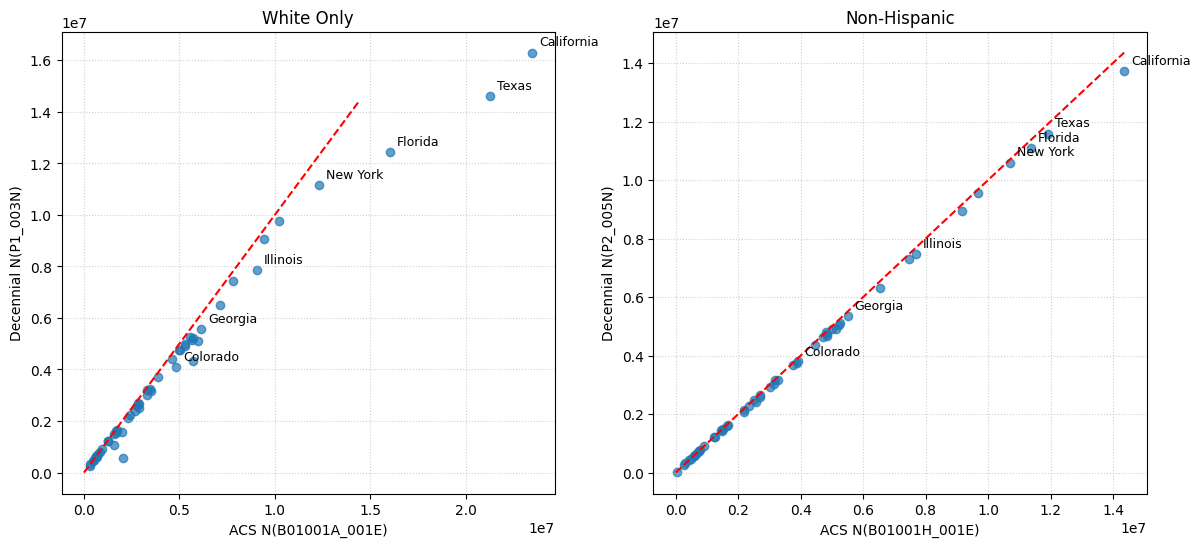

In [165]:
# Create side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: White only 

axs[0].scatter(merged_state['B01001A_001E'], merged_state['P1_003N'], alpha=0.7)

max_val1 = max(merged_state['B01001A_001E'].max(), merged_state['P1_003N'].max())
axs[0].plot([0, max_val], [0, max_val], 'r--', label='1:1 Line')

# Label a few prominent states 
if 'State_Name' in merged_state.columns:
    for i, row in merged_state.iterrows():
        if row['State_Name'] in ['New York', 'Illinois', 'Colorado', 'Georgia', 'Texas', 'California', 'Florida']:
            axs[0].annotate(row['State_Name'], (row['B01001A_001E'], row['P1_003N']), fontsize=9, xytext=(5, 5), textcoords='offset points')


axs[0].set_title('White Only')
axs[0].set_xlabel('ACS N(B01001A_001E)')
axs[0].set_ylabel('Decennial N(P1_003N)')
axs[0].grid(True, linestyle=':', alpha=0.6)


# Right plot: Non-Hispanic
axs[1].scatter(merged_state['B01001H_001E'], merged_state['P2_005N'], alpha=0.7)

max_val2 = max(merged_state['B01001H_001E'].max(), merged_state['P2_005N'].max())
axs[1].plot([0, max_val2], [0, max_val2], 'r--', label='1:1 Line')

# Label a few prominent states 
if 'State_Name' in merged_state.columns:
    for i, row in merged_state.iterrows():
        if row['State_Name'] in ['New York', 'Illinois', 'Colorado', 'Georgia', 'Texas', 'California', 'Florida']:
            axs[1].annotate(row['State_Name'], (row['B01001H_001E'], row['P2_005N']), fontsize=9, xytext=(5, 5), textcoords='offset points')


axs[1].set_title('Non-Hispanic')
axs[1].set_xlabel('ACS N(B01001H_001E)')
axs[1].set_ylabel('Decennial N(P2_005N)')
axs[1].grid(True, linestyle=':', alpha=0.6)

plt.show()

# 2019, 2022 comparison: 1 year ACS

This should highlight that something happened between 2019 and 2022. 

In [175]:
dec_state_df['DEC_HWA'] = dec_state_df['P1_003N'] - dec_state_df['P2_005N']

dec_state_df['State_Name'] = dec_state_df['state'].map(fips_to_state)

acs_vintages = [
    (2022, "acs1"),
    (2019, "acs1")
]

## 2019

In [ ]:
acs_url = "https://api.census.gov/data/2019/acs/acs1"
# Fetch ACS data
acs_state_df = fetch_census_data(acs_url, acs_vars, "state:*")
acs_state_df['B01001A_001E'] = acs_state_df['B01001A_001E'].astype(float)
acs_state_df['B01001H_001E'] = acs_state_df['B01001H_001E'].astype(float)
acs_state_df['ACS_HWA'] = acs_state_df['B01001A_001E'] - acs_state_df['B01001H_001E']

# Merge with Decennial
merged_state = pd.merge(acs_state_df, dec_state_df, on="state")

I make both the scatter plots and histograms:

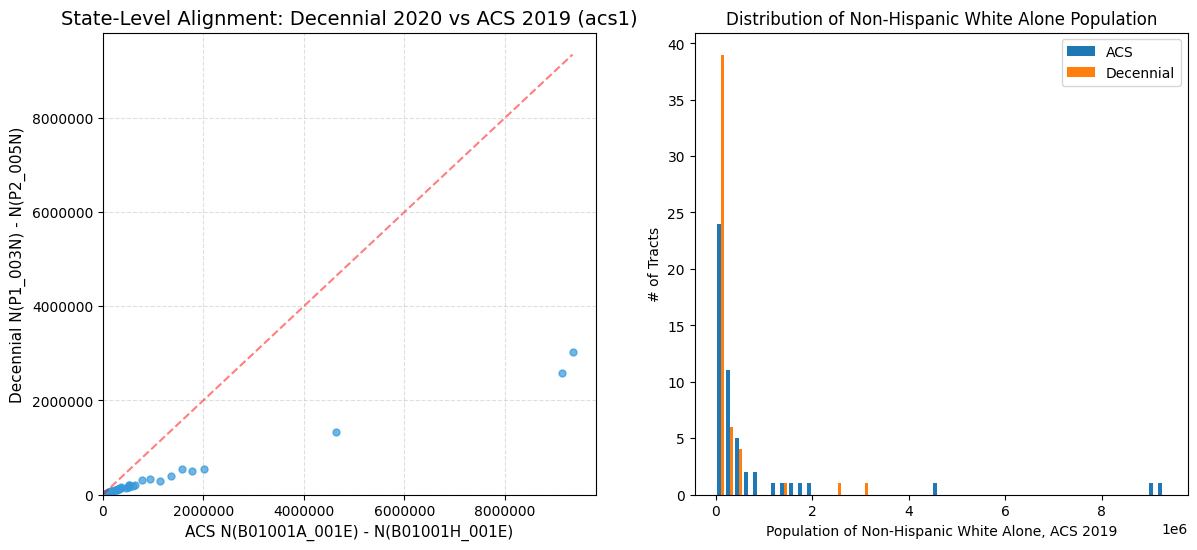

In [204]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

#Left plot: Generate the Scatter Plot
axs[0].scatter(merged_state['ACS_HWA'], merged_state['DEC_HWA'], alpha=0.7, color='#3498db', s=25)

# Add the dashed 1:1 Reference Line
max_val = max(merged_state['ACS_HWA'].max(), merged_state['DEC_HWA'].max())
axs[0].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y = x')

# Annotate specific states to match Chris's notebook output--but I also want to put in California and the big outliers too!
#states_to_label = [
#    'New York', 'Arizona', 'Illinois', 'Colorado', 'California', 
#    'New Jersey', 'Georgia', 'North Carolina', 'Texas',
#    'Indiana', 'Idaho', 'Wisconsin', 'Connecticut', 'New Mexico'
#]

#for i, row in merged_state.iterrows():
#    if pd.notna(row['State_Name']) and row['State_Name'] in states_to_label:
#        # Shift text slightly so it doesn't overlap the dot
#        axs[0].annotate(
#            f"{row['State_Name']}, United States", 
#            (row['ACS_HWA'], row['DEC_HWA']), 
#            fontsize=8, 
#            xytext=(-5, 5), 
#            textcoords='offset points',
#            ha='right'
#        )

# Format the plot
axs[0].set_title('State-Level Alignment: Decennial 2020 vs ACS 2019 (acs1)', fontsize=14)
axs[0].set_xlabel('ACS N(B01001A_001E) - N(B01001H_001E)', fontsize=11)
axs[0].set_ylabel('Decennial N(P1_003N) - N(P2_005N)', fontsize=11)

# Format axes to use non-scientific notation or match math bounds
axs[0].ticklabel_format(style='plain', axis='both')
axs[0].grid(True, linestyle='--', alpha=0.4)
axs[0].set_xlim(left=0)
axs[0].set_ylim(bottom=0)

#Right plot: bar graph

axs[1].hist([merged_state['ACS_HWA'], merged_state['DEC_HWA']], bins=50, label=['ACS', 'Decennial'])
axs[1].set_title('Distribution of Non-Hispanic White Alone Population')
axs[1].set_xlabel('Population of Non-Hispanic White Alone, ACS 2019')
axs[1].set_ylabel('# of Tracts')
axs[1].legend()

plt.show()

If you want to annotate the points, uncomment the middle code above. 

## 2022

In [207]:
acs_url = "https://api.census.gov/data/2022/acs/acs1"
# Fetch ACS data
acs_state_df = fetch_census_data(acs_url, acs_vars, "state:*")
acs_state_df['B01001A_001E'] = acs_state_df['B01001A_001E'].astype(float)
acs_state_df['B01001H_001E'] = acs_state_df['B01001H_001E'].astype(float)
acs_state_df['ACS_HWA'] = acs_state_df['B01001A_001E'] - acs_state_df['B01001H_001E']

# Merge with Decennial
merged_state = pd.merge(acs_state_df, dec_state_df, on="state")

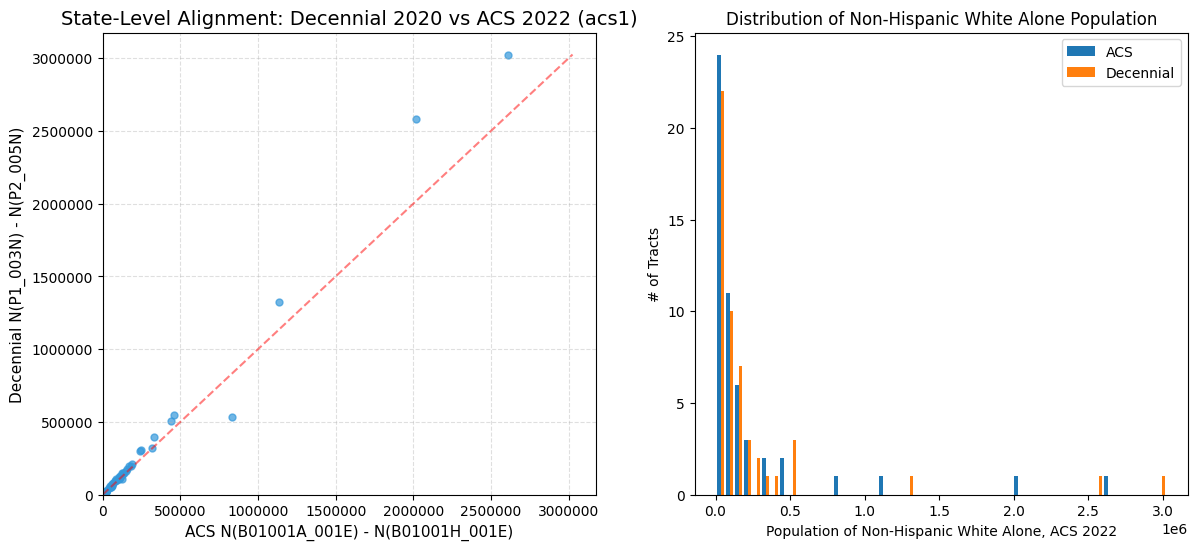

In [209]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

#Left plot: Generate the Scatter Plot
axs[0].scatter(merged_state['ACS_HWA'], merged_state['DEC_HWA'], alpha=0.7, color='#3498db', s=25)

# Add the dashed 1:1 Reference Line
max_val = max(merged_state['ACS_HWA'].max(), merged_state['DEC_HWA'].max())
axs[0].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y = x')

# Annotate specific states to match Chris's notebook output--but I also want to put in California and the big outliers too!
#states_to_label = [
#    'New York', 'Arizona', 'Illinois', 'Colorado', 'California', 
#    'New Jersey', 'Georgia', 'North Carolina', 'Texas',
#    'Indiana', 'Idaho', 'Wisconsin', 'Connecticut', 'New Mexico'
#]

#for i, row in merged_state.iterrows():
#    if pd.notna(row['State_Name']) and row['State_Name'] in states_to_label:
#        # Shift text slightly so it doesn't overlap the dot
#        axs[0].annotate(
#            f"{row['State_Name']}, United States", 
#            (row['ACS_HWA'], row['DEC_HWA']), 
#            fontsize=8, 
#            xytext=(-5, 5), 
#            textcoords='offset points',
#            ha='right'
#        )

# Format the plot
axs[0].set_title('State-Level Alignment: Decennial 2020 vs ACS 2022 (acs1)', fontsize=14)
axs[0].set_xlabel('ACS N(B01001A_001E) - N(B01001H_001E)', fontsize=11)
axs[0].set_ylabel('Decennial N(P1_003N) - N(P2_005N)', fontsize=11)

# Format axes to use non-scientific notation or match math bounds
axs[0].ticklabel_format(style='plain', axis='both')
axs[0].grid(True, linestyle='--', alpha=0.4)
axs[0].set_xlim(left=0)
axs[0].set_ylim(bottom=0)

#Right plot: bar graph

axs[1].hist([merged_state['ACS_HWA'], merged_state['DEC_HWA']], bins=50, label=['ACS', 'Decennial'])
axs[1].set_title('Distribution of Non-Hispanic White Alone Population')
axs[1].set_xlabel('Population of Non-Hispanic White Alone, ACS 2022')
axs[1].set_ylabel('# of Tracts')
axs[1].legend()

plt.show()